## Preventing Customer Churn 

Customer Churn has been decreasing in the last years, and E-Mart wants to make sure to keep it that way.
That's why the company needs to predict which customer is going to stop buying. Data Products asked:

- **A list of customer IDs and their probability of churn.**

- What's the model performance in predicting customer churn?

- What's the monetary return  the model will bring?

## Agenda

[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Customer Analitycal Base Table](#1-Customer-Analitycal-Base-Table)<br>

[2 Train Test Split](#2-Train-Test-Split)<br>

[3 Data Preparation](#3-Data-Preparation)<br>
&emsp;[3.1 Scaling](#3.1-Scaling)<br>
&emsp;[3.2 Feature Encoding](#3.2-Feature-Encoding)<br>

[4 Modeling](#4-Modeling)<br>
&emsp;[4.1 Cross Validation](#4.1-Cross-Validation)<br>

[5.0 Business Impact](#5.0-Business-Impact)<br>

&emsp;[](#)<br>

## 0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Utils
# from imblearn.over_sampling import SMOTE
# from collections import Counter

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

from sklearn.model_selection import cross_validate

# Settings
directory = Directory("pr_v01_customer_churn", is_sub_project=True)
pd.set_option('display.max_columns', None)

%matplotlib inline

### 0.1 Helper Functions

In [2]:
def train_test_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    return y_pred

### 0.2 Loading Data

In [3]:
raw_data = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "e_mart_data.parquet"]))
churned_customers = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "churned_customers.parquet"]))
active_customers = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "active_customers.parquet"]))

In [4]:
raw_data.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,cost,profit_per_product,sales_without_discount,product_value,product_cost,order_date_year,order_date_month,order_date_day,is_profitable_sale
0,42433,AG-2011-2040-TB-11280,2011-01-01,2011-06-01,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,Algeria,NaN,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,266.70,53.070,408.30,186.42,133.350,2011,1,1,1
1,22253,IN-2011-47883-JH-15985,2011-01-01,2011-08-01,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,Australia,NaN,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,74.61,12.012,1116.18,368.82,356.808,2011,1,1,1


In [5]:
churned_customers.head()

,customer_id,recency,churn,year
0,AA-10315,38,False,2011
1,AA-10375,69,False,2011
2,AA-10480,142,False,2011
3,AA-10645,6,False,2011
4,AA-315,148,False,2011


In [6]:
active_customers.head()

,customer_id,order_date,active,year
0,AA-10315,38,True,2011
1,AA-10375,69,True,2011
2,AA-10480,142,True,2011
3,AA-10645,6,True,2011
4,AA-315,148,True,2011


## 1 Customer Analitycal Base Table

**Customer churn tells us the state of customer churn in 2014, so we will use 2013 data to predict 2014 churn.**

In [7]:
p_year = 2014
churn = churned_customers[churned_customers['year'] == p_year][['customer_id', 'churn']]

In [8]:
years = [2013]

data = raw_data.copy()
CURRENT_DATE = pd.to_datetime(f"01/01/{years[-1]+1}")

In [9]:
aux = data[data['order_date_year'].isin(years)]

agg = {
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean', # do not sum* - if we sum the discounts we'll see discounts greater than 1.0 (100%)
    'is_profitable_sale': 'mean',
    'shipping_cost':'sum', # we'll consider then that the same database modeling happened to shipping_cost? No
}
customer_abt_orders = aux.groupby(['customer_id', 'order_id']).agg(agg).reset_index()
customer_abt_orders.columns = ['customer_id', 'orders', 'total_sales', 'quantity',
                               'total_profit', 'avg_discount', 'is_profitable_sale', 'total_shipping_cost' ]
# customer_abt['avg_discount'].hist(); # if we sum the discounts we'll see discounts greater than 1.0 (100%)
# customer_abt['total_shipping_cost'].hist(); # No

customer_abt_orders

second_agg = {
    'orders':'nunique',
    'total_sales':'sum',
    'quantity':'sum',
    'total_profit':'sum',
    'avg_discount':'mean',
    'is_profitable_sale': 'mean',
    'total_shipping_cost':'sum',
}
customer_abt = customer_abt_orders.groupby('customer_id').agg(second_agg).reset_index()
customer_abt.head(3)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost
0,AA-10315,6,5385.540,35,-439.8641,0.050000,0.958333,416.37
1,AA-10375,6,1469.888,46,-577.6392,0.329167,0.441667,347.43
2,AA-10480,3,2919.030,36,615.6786,0.033333,1.000000,145.68


In [10]:
agg = {
    'product_id':'nunique',
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean', # do not sum* - if we sum the discounts we'll see discounts greater than 1.0 (100%)
    'is_profitable_sale': 'mean',
    'shipping_cost':'sum', # we'll consider then that the same database modeling happened to shipping_cost? No
}
customer_abt_orders = aux.groupby(['customer_id', 'order_id']).agg(agg).reset_index()
customer_abt_orders.columns = ['customer_id', 'order_id', 'distinct_products', 'avg_ticket', 'quantity',
                               'avg_profit', 'avg_discount', 'is_profitable_sale', 'avg_shipping_cost' ]

customer_abt_orders.drop(columns=['order_id', 'quantity', 'is_profitable_sale', 'avg_discount'], inplace=True)
customer_abt_orders

second_agg = {
    'avg_ticket':'mean',
    'distinct_products':'sum',
    'avg_profit':'mean',
    'avg_shipping_cost':'mean',
}
customer_abt_averages = customer_abt_orders.groupby('customer_id').agg(second_agg).reset_index()
customer_abt_averages.head(3)

,customer_id,avg_ticket,distinct_products,avg_profit,avg_shipping_cost
0,AA-10315,897.590000,11,-73.310683,69.395
1,AA-10375,244.981333,16,-96.273200,57.905
2,AA-10480,973.010000,11,205.226200,48.560


In [11]:
customer_abt = customer_abt.merge(customer_abt_averages, on='customer_id', how='outer')#.isna().sum()
customer_abt.head(3)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost,avg_ticket,distinct_products,avg_profit,avg_shipping_cost
0,AA-10315,6,5385.540,35,-439.8641,0.050000,0.958333,416.37,897.590000,11,-73.310683,69.395
1,AA-10375,6,1469.888,46,-577.6392,0.329167,0.441667,347.43,244.981333,16,-96.273200,57.905
2,AA-10480,3,2919.030,36,615.6786,0.033333,1.000000,145.68,973.010000,11,205.226200,48.560


In [12]:
recency_last_year = churned_customers[churned_customers['year'].isin(years)][['customer_id', 'recency']]
active = active_customers[active_customers['year'].isin(years)][['customer_id', 'active']]

customer_abt = customer_abt.merge(recency_last_year, on='customer_id', how='outer')
customer_abt = customer_abt.merge(active, on='customer_id', how='outer')
customer_abt = customer_abt.merge(churn, on='customer_id', how='outer')

**Missing Value comes from Future Customers, since We are using 2013 to predict 2014, due to Feature Filtering and Selection We have 2014 customer IDs but not their data**

In [13]:
customer_abt.isna().sum() 

customer_id              0
orders                 132
total_sales            132
quantity               132
total_profit           132
avg_discount           132
is_profitable_sale     132
total_shipping_cost    132
avg_ticket             132
distinct_products      132
avg_profit             132
avg_shipping_cost      132
recency                 15
active                  15
churn                    0
dtype: int64

In [14]:
customer_abt.dropna(inplace=True)

## 2 Train Test Split

    Too few observations.

In [90]:
customer_abt['churn'].mean(), customer_abt['churn'].value_counts()

(0.1337448559670782,
 False    1263
 True      195
 Name: churn, dtype: int64)

In [167]:
df = customer_abt.copy()

# Undersampling
aux_target = df[df['churn'] == True]
churn_len =  len(aux_target) * 2

aux = df[df['churn'] == False].sample(churn_len)

df = aux.append(aux_target)

In [174]:
# X = df.drop(columns=['customer_id', 'churn'])
X = df[['distinct_products', 'avg_shipping_cost', 'recency', 'total_shipping_cost', 'total_sales', 'quantity']]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [175]:
y.mean()

0.3333333333333333

## 3 Data Preparation

### 3.1 Scaling

### 3.2 Feature Encoding

## 4 Modeling

**1st RandomForest**

        Precision   Recall
           0.43      0.11
           
**2nd RandomForest**

Undesampling - Target represents 13% of data to 33%.

        Precision   Recall
           0.65      0.54
           0.56      0.46 (After Feature Selection)

In [176]:
model = RandomForestClassifier(random_state=0, n_estimators=300, min_samples_leaf=3)
predictions = train_test_model(model,  X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

       False       0.73      0.80      0.76       113
        True       0.56      0.46      0.50        63

    accuracy                           0.68       176
   macro avg       0.64      0.63      0.63       176
weighted avg       0.67      0.68      0.67       176



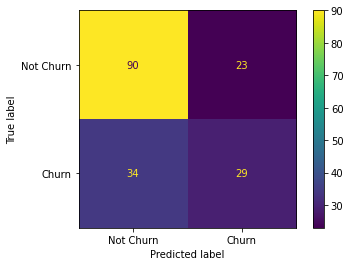

In [178]:
plot_confusion_matrix(model, X_test, y_test, display_labels=['Not Churn', 'Churn'])
plt.show()

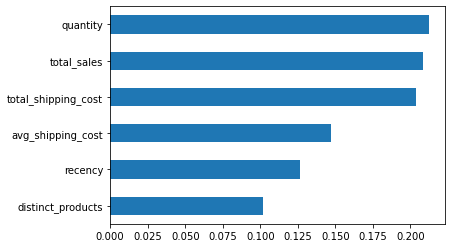

In [179]:
feature_importances = pd.Series( model.feature_importances_, index = X_test.columns ).sort_values()
feature_importances.plot(kind='barh');
plt.show()

In [180]:
# feature_importances.tail(6).index

### 4.1 Cross Validation

In [206]:
cv = cross_validate(model, X, y, cv=5, scoring=['precision','recall'])
precision = round(cv['test_precision'].mean(), 2)
precision_std = round(cv['test_precision'].std(), 2)
recall = round(cv['test_recall'].mean(), 2)
recall_worst = round(cv['test_recall'].min(), 2)
recall_std = round(cv['test_recall'].std(), 2)
print(f"Precision: {precision} +- {precision_std}")
print(f"Recall:    {recall} +- {recall_std}")

Precision: 0.58 +- 0.07
Recall:    0.45 +- 0.02


## 5.0 Business Impact 

### (Annual)

In [204]:
revenue_per_churned_customer = customer_abt[customer_abt['churn'] == True]['total_sales'].mean()
retained_revenue = (churn['churn'].sum() * recall) * revenue_per_churned_customer
retained_revenue_best = (churn['churn'].sum() * (recall+recall_std)) * revenue_per_churned_customer
retained_revenue_worst = (churn['churn'].sum() * (recall_worst)) * revenue_per_churned_customer

emart_annual_revenue = raw_data[raw_data['order_date_year'] == p_year]['sales'].sum()
percentual_change = ((retained_revenue + emart_annual_revenue) - emart_annual_revenue) / emart_annual_revenue * 100
percentual_change_best = ((retained_revenue_best + emart_annual_revenue) - emart_annual_revenue) / emart_annual_revenue * 100
percentual_change_worst = ((retained_revenue_worst + emart_annual_revenue) - emart_annual_revenue) / emart_annual_revenue * 100

In [205]:
print(f"We expect the Model to Identify: {round(recall*100)}% of Customers who will Churn.")
print(f"The Average Annual Revenue from a Churned Customer is $ {round(revenue_per_churned_customer)}.")
print()
print(f"For {p_year} conditions We would expect to have an increase in revenue of $ {round(retained_revenue)}")
print(f"Which means an annual revenue {round(percentual_change, 2)}% Greater than what it was")
print()
print(f"\tThe Worst Scenario would be:")
print(f"Model identifying {round(recall_worst*100)}% of Customers who will Churn.")
print(f"Increase in revenue: $ {round(retained_revenue_worst)}.")
print(f"annual revenue {round(percentual_change_worst, 2)}% Greater than what it was.")
print()
print(f"\tAs for the Best Scenario:")
print(f"Model identifying {round((recall+recall_std)*100)}% of Customers who will Churn.")
print(f"Increase in revenue: $ {round(retained_revenue_best)}.")
print(f"annual revenue {round(percentual_change_best, 2)}% Greater than what it was.")

We expect the Model to Identify: 45% of Customers who will Churn.
The Average Annual Revenue from a Churned Customer is $ 773.

For 2014 conditions We would expect to have an increase in revenue of $ 78944
Which means an annual revenue 1.84% Greater than what it was

	The Worst Scenario would be:
Model identifying 41% of Customers who will Churn.
Increase in revenue: $ 71927.
annual revenue 1.67% Greater than what it was.

	As for the Best Scenario:
Model identifying 47% of Customers who will Churn.
Increase in revenue: $ 82452.
annual revenue 1.92% Greater than what it was.


In [190]:
churned_customers.groupby('year')[['churn']].mean().T

year,2011,2012,2013,2014
churn,0.177235,0.233706,0.190476,0.142767


In [188]:
# customers_quantity_pct_change = active_customers.groupby('year')[['active']].sum().pct_change().mean()
# active_customers[active_customers['year'] == 2014]['active'].sum() * (1+customers_quantity_pct_change)